BEHAVIORAL FEATURES USED FOR SEGMENTATION

Price Behavior (4 features):
  ✓ UnitPrice_mean_x
  ✓ UnitPrice_std_x
  ✓ UnitPrice_min_x
  ✓ UnitPrice_max_x

Sales Behavior (3 features):
  ✓ SalesQty_sum
  ✓ SalesQty_mean
  ✓ SalesQty_std

Revenue Behavior (2 features):
  ✓ ExtPrice_sum
  ✓ ExtPrice_mean

Cost Behavior (3 features):
  ✓ ExtCost_sum
  ✓ ExtCost_mean
  ✓ ExtCost_std

Customer Behavior (2 features):
  ✓ OrdersPerCustomer
  ✓ RevenuePerCustomer

Lifecycle Behavior (2 features):
  ✓ AvgDaysBetweenOrders
  ✓ SalesDate_count

Quote Behavior (4 features):
  ✓ QuoteQty_sum
  ✓ QuoteID_nunique
  ✓ QuoteConversionRate
  ✓ QuoteWinRate

TOTAL FEATURES FOR CLUSTERING: 20

Products after removing missing values: 40359 (from 40359 original)

Performing K-Means clustering with 3 segments...

Calculating performance score using 8 key metrics:
  • Sales Volume: SalesQty_sum, SalesQty_mean
  • Revenue Generation: ExtPrice_sum, ExtPrice_mean
  • Customer Engagement: OrdersPerCustomer, Revenue

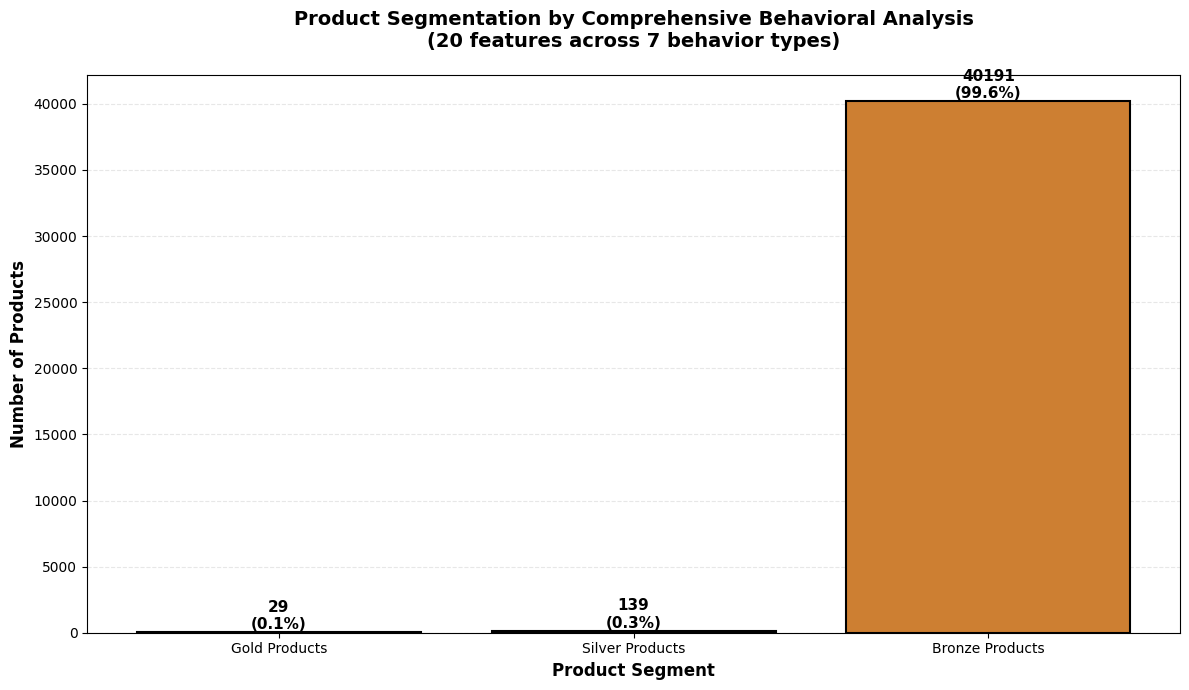


PRODUCT SEGMENTATION SUMMARY
Total Products Analyzed: 40359
Behavioral Dimensions: 7
Total Features Used: 20

Segment Distribution:
  🥇 Gold Products: 29 products (0.1%) - Performance: 0.2537
  🥈 Silver Products: 139 products (0.3%) - Performance: 0.1837
  🥉 Bronze Products: 40191 products (99.6%) - Performance: 0.1244


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Load data
path = r"c:\Users\Araya\Desktop\product_features_enhanced (1).csv"
df = pd.read_csv(path)

# COMPREHENSIVE BEHAVIORAL FEATURE SET
# Organized by behavior type for better understanding
behavioral_features = {
    'Price Behavior': ['UnitPrice_mean_x', 'UnitPrice_std_x', 'UnitPrice_min_x', 'UnitPrice_max_x'],
    'Sales Behavior': ['SalesQty_sum', 'SalesQty_mean', 'SalesQty_std'],
    'Revenue Behavior': ['ExtPrice_sum', 'ExtPrice_mean'],
    'Cost Behavior': ['ExtCost_sum', 'ExtCost_mean', 'ExtCost_std'],
    'Customer Behavior': ['OrdersPerCustomer', 'RevenuePerCustomer'],
    'Lifecycle Behavior': ['AvgDaysBetweenOrders', 'SalesDate_count'],
    'Quote Behavior': ['QuoteQty_sum', 'QuoteID_nunique', 'QuoteConversionRate', 'QuoteWinRate']
}

# Flatten and check which features are available
all_features = []
available_by_category = {}

print("="*70)
print("BEHAVIORAL FEATURES USED FOR SEGMENTATION")
print("="*70)

for behavior_type, features_list in behavioral_features.items():
    available_features = [f for f in features_list if f in df.columns]
    if available_features:
        all_features.extend(available_features)
        available_by_category[behavior_type] = available_features
        print(f"\n{behavior_type} ({len(available_features)} features):")
        for feat in available_features:
            print(f"  ✓ {feat}")
    else:
        print(f"\n{behavior_type}: ⚠ No features available")

print(f"\n{'='*70}")
print(f"TOTAL FEATURES FOR CLUSTERING: {len(all_features)}")
print(f"{'='*70}\n")

# Clean data - only keep rows with all behavioral features
df_clean = df[all_features].dropna().copy()
print(f"Products after removing missing values: {len(df_clean)} (from {len(df)} original)")

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)

# KMeans clustering (3 groups)
print("\nPerforming K-Means clustering with 3 segments...")
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
df_clean["Cluster"] = clusters

# Calculate COMPREHENSIVE Business Performance Score
# Weight different behavioral categories
performance_components = {
    'Sales Volume': ['SalesQty_sum', 'SalesQty_mean'],
    'Revenue Generation': ['ExtPrice_sum', 'ExtPrice_mean'],
    'Customer Engagement': ['OrdersPerCustomer', 'RevenuePerCustomer'],
    'Conversion Efficiency': ['QuoteConversionRate', 'QuoteWinRate'] if 'QuoteWinRate' in df_clean.columns else ['QuoteConversionRate']
}

# Add profit if available
if 'totalprofit' in df.columns:
    df_clean['totalprofit'] = df.loc[df_clean.index, 'totalprofit']
    performance_components['Profitability'] = ['totalprofit']

# Collect all performance metrics for naming
all_performance_metrics = []
for category, metrics in performance_components.items():
    for metric in metrics:
        if metric in df_clean.columns:
            all_performance_metrics.append(metric)

print(f"\nCalculating performance score using {len(all_performance_metrics)} key metrics:")
for category, metrics in performance_components.items():
    available = [m for m in metrics if m in df_clean.columns]
    if available:
        print(f"  • {category}: {', '.join(available)}")

# Normalize each metric to 0-1 scale
performance_scores = df_clean[all_performance_metrics].copy()
for col in all_performance_metrics:
    min_val = performance_scores[col].min()
    max_val = performance_scores[col].max()
    if max_val > min_val:
        performance_scores[col] = (performance_scores[col] - min_val) / (max_val - min_val)
    else:
        performance_scores[col] = 0

# Calculate average performance score
df_clean['PerformanceScore'] = performance_scores.mean(axis=1)

# Rank clusters by comprehensive performance score
perf_mean = df_clean.groupby("Cluster")["PerformanceScore"].mean().sort_values()
order = perf_mean.index.tolist()

print(f"\n{'='*70}")
print("CLUSTER PERFORMANCE RANKING")
print(f"{'='*70}")
for idx, cluster_id in enumerate(order):
    score = perf_mean[cluster_id]
    tier = 'Bronze' if idx==0 else 'Silver' if idx==1 else 'Gold'
    print(f"  {tier} Tier (Cluster {cluster_id}): Performance Score = {score:.4f}")

# Map clusters to Gold/Silver/Bronze
name_map = {
    order[0]: "Bronze Products",
    order[1]: "Silver Products",
    order[2]: "Gold Products"
}

df_clean["Segment"] = df_clean["Cluster"].map(name_map)

# Count per segment
segment_counts = df_clean["Segment"].value_counts().reindex(["Gold Products", "Silver Products", "Bronze Products"])

# Create beautiful bar chart
plt.figure(figsize=(12, 7))
colors = ['#FFD700', '#C0C0C0', '#CD7F32']  # Gold, Silver, Bronze colors
bars = plt.bar(segment_counts.index, segment_counts.values, color=colors, edgecolor='black', linewidth=1.5)

plt.title(f"Product Segmentation by Comprehensive Behavioral Analysis\n({len(all_features)} features across {len(available_by_category)} behavior types)", 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Product Segment", fontsize=12, fontweight='bold')
plt.ylabel("Number of Products", fontsize=12, fontweight='bold')

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, segment_counts.values)):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(val)}\n({val/segment_counts.sum()*100:.1f}%)',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# Add grid for better readability
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.gca().set_axisbelow(True)

plt.tight_layout()

# Save
out_path = "product_segment_gold_silver_bronze.png"
plt.savefig(out_path, dpi=300, bbox_inches='tight')
print(f"\n{'='*70}")
print(f"Chart saved to: {out_path}")
print(f"{'='*70}")

# Display the plot
plt.show()

# Print summary
print("\n" + "="*70)
print("PRODUCT SEGMENTATION SUMMARY")
print("="*70)
print(f"Total Products Analyzed: {len(df_clean)}")
print(f"Behavioral Dimensions: {len(available_by_category)}")
print(f"Total Features Used: {len(all_features)}")
print("\nSegment Distribution:")
for segment in ["Gold Products", "Silver Products", "Bronze Products"]:
    count = segment_counts[segment]
    pct = (count / len(df_clean)) * 100
    avg_score = df_clean[df_clean['Segment'] == segment]['PerformanceScore'].mean()
    emoji = "🥇" if "Gold" in segment else "🥈" if "Silver" in segment else "🥉"
    print(f"  {emoji} {segment}: {count} products ({pct:.1f}%) - Performance: {avg_score:.4f}")


In [28]:
# Analyze cluster characteristics by behavior type
print("=" * 80)
print("BEHAVIORAL PROFILE ANALYSIS: Gold, Silver, Bronze Products")
print("=" * 80)

segment_order = ["Gold Products", "Silver Products", "Bronze Products"]

# Analyze each behavior category separately
for behavior_type, features_list in available_by_category.items():
    print(f"\n{'─'*80}")
    print(f"{behavior_type.upper()}")
    print(f"{'─'*80}")
    
    behavior_profile = df_clean.groupby("Segment")[features_list].mean().reindex(segment_order)
    print(behavior_profile.round(2))
    
    # Show which segment excels in this behavior
    best_segment = behavior_profile.mean(axis=1).idxmax()
    print(f"  → Best performing: {best_segment}")

# Overall performance score comparison
print(f"\n{'='*80}")
print("OVERALL PERFORMANCE SCORES")
print(f"{'='*80}")
perf_comparison = df_clean.groupby("Segment")['PerformanceScore'].agg(['mean', 'std', 'min', 'max']).reindex(segment_order)
print(perf_comparison.round(4))

# Profit analysis if available
if 'totalprofit' in df_clean.columns:
    print(f"\n{'='*80}")
    print("PROFIT ANALYSIS BY SEGMENT")
    print(f"{'='*80}")
    
    profit_summary = df_clean.groupby("Segment").agg({
        'totalprofit': ['sum', 'mean', 'median', 'std']
    }).reindex(segment_order)
    
    print(profit_summary.round(2))
    
    total_profit = profit_summary[('totalprofit', 'sum')].sum()
    print(f"\nTotal Profit: ${total_profit:,.2f}")
    
    # Profit contribution
    print("\nProfit Contribution by Segment:")
    for segment in segment_order:
        seg_profit = profit_summary.loc[segment, ('totalprofit', 'sum')]
        contribution = (seg_profit / total_profit) * 100
        emoji = "🥇" if "Gold" in segment else "🥈" if "Silver" in segment else "🥉"
        print(f"  {emoji} {segment}: ${seg_profit:,.2f} ({contribution:.1f}%)")

# Segment distribution
print(f"\n{'='*80}")
print("SEGMENT DISTRIBUTION")
print(f"{'='*80}")
segment_sizes = df_clean["Segment"].value_counts().reindex(segment_order)
print(f"\nTotal Products: {len(df_clean)}")
print("\nProducts per segment:")
for segment, count in segment_sizes.items():
    pct = (count / len(df_clean)) * 100
    emoji = "🥇" if "Gold" in segment else "🥈" if "Silver" in segment else "🥉"
    print(f"  {emoji} {segment}: {count} ({pct:.1f}%)")


BEHAVIORAL PROFILE ANALYSIS: Gold, Silver, Bronze Products

────────────────────────────────────────────────────────────────────────────────
PRICE BEHAVIOR
────────────────────────────────────────────────────────────────────────────────
                 UnitPrice_mean_x  UnitPrice_std_x  UnitPrice_min_x  \
Segment                                                               
Gold Products               20.50             3.13            14.51   
Silver Products           2240.51           347.00          2011.41   
Bronze Products             49.16             3.93            45.18   

                 UnitPrice_max_x  
Segment                           
Gold Products              60.17  
Silver Products          2982.92  
Bronze Products            55.91  
  → Best performing: Silver Products

────────────────────────────────────────────────────────────────────────────────
SALES BEHAVIOR
────────────────────────────────────────────────────────────────────────────────
                 

Performance comparison chart saved to: segment_performance_gold_silver_bronze.png


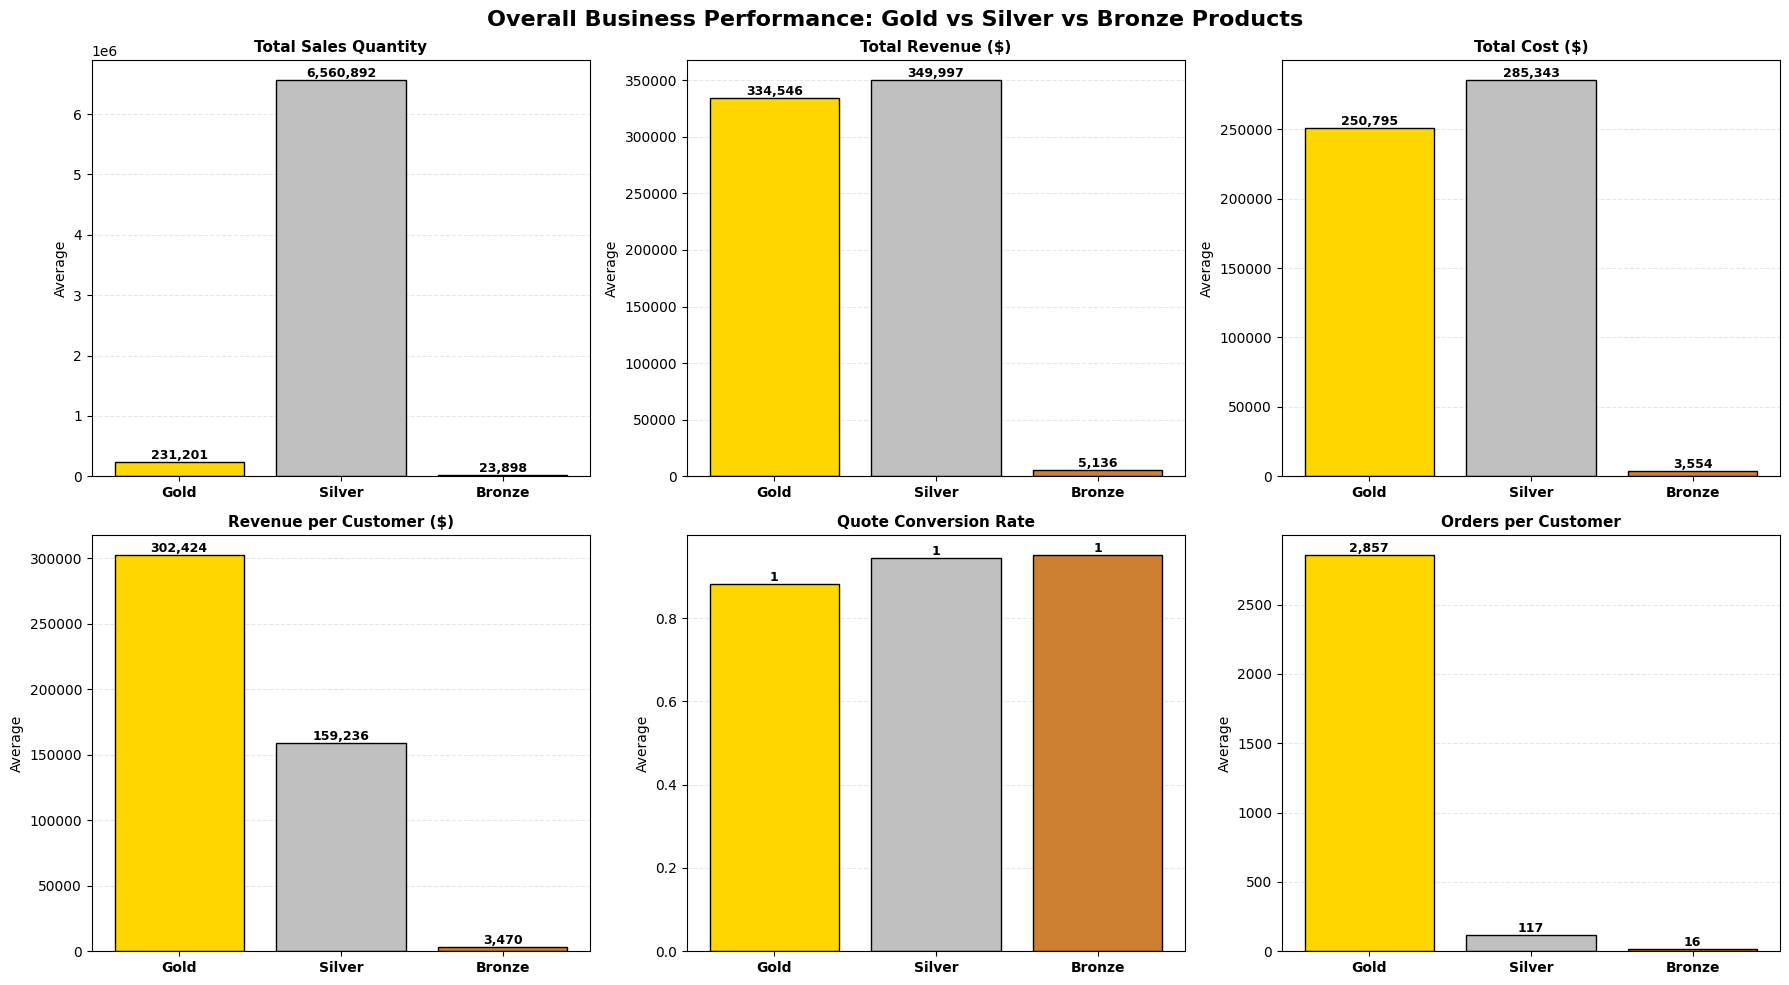

In [29]:
# Visualize key business performance metrics by segment
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Overall Business Performance: Gold vs Silver vs Bronze Products', fontsize=16, fontweight='bold')

# Key metrics to visualize
metrics = [
    ('SalesQty_sum', 'Total Sales Quantity'),
    ('ExtPrice_sum', 'Total Revenue ($)'),
    ('ExtCost_sum', 'Total Cost ($)'),
    ('RevenuePerCustomer', 'Revenue per Customer ($)'),
    ('QuoteConversionRate', 'Quote Conversion Rate'),
    ('OrdersPerCustomer', 'Orders per Customer')
]

# Segment order and colors
segment_order = ["Gold Products", "Silver Products", "Bronze Products"]
colors = ['#FFD700', '#C0C0C0', '#CD7F32']  # Gold, Silver, Bronze

# Create bar plots for each metric
for idx, (metric, title) in enumerate(metrics):
    ax = axes[idx // 3, idx % 3]
    
    if metric in df_clean.columns:
        data = df_clean.groupby("Segment")[metric].mean().reindex(segment_order)
        bars = ax.bar(range(len(data)), data.values, color=colors, edgecolor='black', linewidth=1)
        
        ax.set_xticks(range(len(data)))
        ax.set_xticklabels(['Gold', 'Silver', 'Bronze'], fontweight='bold')
        ax.set_title(title, fontweight='bold', fontsize=11)
        ax.set_ylabel('Average')
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.set_axisbelow(True)
        
        # Add value labels on bars
        for i, v in enumerate(data.values):
            ax.text(i, v, f'{v:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    else:
        ax.text(0.5, 0.5, f'{metric}\nnot available', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title, fontweight='bold')

plt.tight_layout()
plt.savefig('segment_performance_gold_silver_bronze.png', dpi=300, bbox_inches='tight')
print("Performance comparison chart saved to: segment_performance_gold_silver_bronze.png")
plt.show()

# If profit data exists, create a profit-focused visualization
if 'totalprofit' in df.columns:
    df_clean_with_profit = df_clean.copy()
    df_clean_with_profit['totalprofit'] = df.loc[df_clean.index, 'totalprofit']
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle('Profitability Analysis: Gold, Silver & Bronze Products', fontsize=14, fontweight='bold')
    
    # Total profit by segment
    profit_totals = df_clean_with_profit.groupby("Segment")['totalprofit'].sum().reindex(segment_order)
    bars1 = ax1.bar(range(len(profit_totals)), profit_totals.values, color=colors, edgecolor='black', linewidth=1.5)
    ax1.set_title('Total Profit by Segment', fontweight='bold')
    ax1.set_ylabel('Total Profit ($)', fontweight='bold')
    ax1.set_xticks(range(len(profit_totals)))
    ax1.set_xticklabels(['Gold', 'Silver', 'Bronze'], fontweight='bold')
    ax1.grid(axis='y', alpha=0.3, linestyle='--')
    ax1.set_axisbelow(True)
    
    for i, v in enumerate(profit_totals.values):
        ax1.text(i, v, f'${v:,.0f}', ha='center', va='bottom', fontweight='bold')
    
    # Average profit per product
    profit_avg = df_clean_with_profit.groupby("Segment")['totalprofit'].mean().reindex(segment_order)
    bars2 = ax2.bar(range(len(profit_avg)), profit_avg.values, color=colors, edgecolor='black', linewidth=1.5)
    ax2.set_title('Average Profit per Product', fontweight='bold')
    ax2.set_ylabel('Average Profit ($)', fontweight='bold')
    ax2.set_xticks(range(len(profit_avg)))
    ax2.set_xticklabels(['Gold', 'Silver', 'Bronze'], fontweight='bold')
    ax2.grid(axis='y', alpha=0.3, linestyle='--')
    ax2.set_axisbelow(True)
    
    for i, v in enumerate(profit_avg.values):
        ax2.text(i, v, f'${v:,.0f}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('segment_profitability_gold_silver_bronze.png', dpi=300, bbox_inches='tight')
    print("Profitability chart saved to: segment_profitability_gold_silver_bronze.png")
    plt.show()


In [30]:
# DETAILED RANGE ANALYSIS: What "Low", "Medium", "High" Actually Mean
print("=" * 90)
print("BEHAVIORAL RANGE ANALYSIS: Defining Low/Medium/High for Each Segment")
print("=" * 90)

segment_order = ["Gold Products", "Silver Products", "Bronze Products"]

# Analyze each behavioral category with ranges
for behavior_type, features_list in available_by_category.items():
    print(f"\n{'═'*90}")
    print(f"{behavior_type.upper()}")
    print(f"{'═'*90}")
    
    for feature in features_list:
        print(f"\n  📊 {feature}")
        print(f"  {'-'*86}")
        
        # Get statistics for each segment
        segment_stats = df_clean.groupby("Segment")[feature].agg(['min', 'mean', 'max', 'std']).reindex(segment_order)
        
        # Overall range
        overall_min = df_clean[feature].min()
        overall_max = df_clean[feature].max()
        overall_mean = df_clean[feature].mean()
        
        print(f"  Overall Range: {overall_min:.2f} to {overall_max:.2f} (Mean: {overall_mean:.2f})")
        print(f"  {'─'*86}")
        
        for segment in segment_order:
            emoji = "🥇" if "Gold" in segment else "🥈" if "Silver" in segment else "🥉"
            stats = segment_stats.loc[segment]
            
            # Calculate what percentile this segment's mean represents
            percentile = (stats['mean'] - overall_min) / (overall_max - overall_min) * 100 if overall_max > overall_min else 50
            
            print(f"  {emoji} {segment}:")
            print(f"      Range: {stats['min']:.2f} - {stats['max']:.2f}")
            print(f"      Average: {stats['mean']:.2f} (±{stats['std']:.2f})")
            print(f"      Relative Position: {percentile:.1f}th percentile")
            
            # Interpretation
            if percentile < 33:
                level = "LOW"
            elif percentile < 67:
                level = "MEDIUM"
            else:
                level = "HIGH"
            print(f"      Level: {level}")
            print()

# Performance Score Distribution
print(f"\n{'═'*90}")
print("OVERALL PERFORMANCE SCORE DISTRIBUTION")
print(f"{'═'*90}")

overall_perf_min = df_clean['PerformanceScore'].min()
overall_perf_max = df_clean['PerformanceScore'].max()
overall_perf_mean = df_clean['PerformanceScore'].mean()

print(f"\nPerformance Score Range: {overall_perf_min:.4f} to {overall_perf_max:.4f}")
print(f"Overall Mean: {overall_perf_mean:.4f}\n")

for segment in segment_order:
    emoji = "🥇" if "Gold" in segment else "🥈" if "Silver" in segment else "🥉"
    segment_data = df_clean[df_clean['Segment'] == segment]['PerformanceScore']
    
    print(f"{emoji} {segment}:")
    print(f"   Score Range: {segment_data.min():.4f} - {segment_data.max():.4f}")
    print(f"   Average Score: {segment_data.mean():.4f} (±{segment_data.std():.4f})")
    print(f"   Median Score: {segment_data.median():.4f}")
    
    # Define thresholds
    if segment_data.mean() < overall_perf_mean * 0.8:
        print(f"   Classification: UNDERPERFORMING (< 80% of mean)")
    elif segment_data.mean() > overall_perf_mean * 1.2:
        print(f"   Classification: OUTPERFORMING (> 120% of mean)")
    else:
        print(f"   Classification: AVERAGE PERFORMING (80-120% of mean)")
    print()

print(f"{'═'*90}")
print("INTERPRETATION GUIDE")
print(f"{'═'*90}")
print("""
When we say Bronze is "lower":
- It means Bronze products score in the BOTTOM THIRD compared to all products
- It's a RELATIVE comparison within your product catalog
- Not an absolute threshold (e.g., "sales below 100 units")

Example: If Gold averages 1000 sales, Silver 500, Bronze 100:
  → Bronze is "low" relative to Gold, but 100 sales might still be acceptable
  
The segmentation helps you identify:
  ✓ Which products are performing BETTER than others
  ✓ Which products need DIFFERENT strategies
  ✓ Where to focus IMPROVEMENT efforts
""")

BEHAVIORAL RANGE ANALYSIS: Defining Low/Medium/High for Each Segment

══════════════════════════════════════════════════════════════════════════════════════════
PRICE BEHAVIOR
══════════════════════════════════════════════════════════════════════════════════════════

  📊 UnitPrice_mean_x
  --------------------------------------------------------------------------------------
  Overall Range: 0.00 to 30600.00 (Mean: 56.69)
  ──────────────────────────────────────────────────────────────────────────────────────
  🥇 Gold Products:
      Range: 0.06 - 101.77
      Average: 20.50 (±34.24)
      Relative Position: 0.1th percentile
      Level: LOW

  🥈 Silver Products:
      Range: 0.00 - 30600.00
      Average: 2240.51 (±4368.04)
      Relative Position: 7.3th percentile
      Level: LOW

  🥉 Bronze Products:
      Range: 0.00 - 4385.06
      Average: 49.16 (±180.67)
      Relative Position: 0.2th percentile
      Level: LOW


  📊 UnitPrice_std_x
  ------------------------------------------

In [ ]:
# CORRELATION MATRIX HEATMAP
# Shows relationships between all behavioral features
import seaborn as sns

print("=" * 80)
print("FEATURE CORRELATION ANALYSIS")
print("=" * 80)

# Calculate correlation matrix for all behavioral features
correlation_matrix = df_clean[all_features].corr()

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('Feature Correlation Analysis', fontsize=16, fontweight='bold')

# Plot 1: Full correlation heatmap
sns.heatmap(correlation_matrix, 
            annot=False,  # Don't show numbers (too many features)
            cmap='coolwarm', 
            center=0,
            vmin=-1, vmax=1,
            square=True,
            linewidths=0.5,
            cbar_kws={'label': 'Correlation Coefficient'},
            ax=ax1)
ax1.set_title('All Features Correlation Matrix', fontweight='bold', fontsize=12)
ax1.set_xlabel('Features', fontweight='bold')
ax1.set_ylabel('Features', fontweight='bold')

# Rotate labels for better readability
plt.setp(ax1.get_xticklabels(), rotation=45, ha='right', fontsize=8)
plt.setp(ax1.get_yticklabels(), rotation=0, fontsize=8)

# Plot 2: Performance metrics correlation only
if 'PerformanceScore' in df_clean.columns:
    # Get correlations with performance score
    perf_correlations = df_clean[all_features + ['PerformanceScore']].corr()['PerformanceScore'].drop('PerformanceScore')
    perf_correlations = perf_correlations.sort_values(ascending=False)
    
    # Create bar plot
    colors_bar = ['#2ca02c' if x > 0 else '#d62728' for x in perf_correlations.values]
    bars = ax2.barh(range(len(perf_correlations)), perf_correlations.values, color=colors_bar, edgecolor='black', linewidth=0.5)
    
    ax2.set_yticks(range(len(perf_correlations)))
    ax2.set_yticklabels(perf_correlations.index, fontsize=8)
    ax2.set_xlabel('Correlation with Performance Score', fontweight='bold')
    ax2.set_title('Feature Impact on Overall Performance', fontweight='bold', fontsize=12)
    ax2.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    ax2.grid(axis='x', alpha=0.3, linestyle='--')
    
    # Add value labels
    for i, (bar, val) in enumerate(zip(bars, perf_correlations.values)):
        ax2.text(val, i, f' {val:.3f}', va='center', ha='left' if val > 0 else 'right', fontsize=7)

plt.tight_layout()
plt.savefig('feature_correlation_heatmap.png', dpi=300, bbox_inches='tight')
print("\nCorrelation heatmap saved to: feature_correlation_heatmap.png")
plt.show()

# Print top correlations with performance score
if 'PerformanceScore' in df_clean.columns:
    print("\n" + "="*80)
    print("TOP FEATURES CORRELATED WITH PERFORMANCE SCORE")
    print("="*80)
    
    print("\n🔼 POSITIVE CORRELATIONS (Higher = Better Performance):")
    top_positive = perf_correlations[perf_correlations > 0].head(10)
    for i, (feature, corr) in enumerate(top_positive.items(), 1):
        print(f"  {i}. {feature}: {corr:.4f}")
    
    print("\n🔽 NEGATIVE CORRELATIONS (Lower = Better Performance):")
    top_negative = perf_correlations[perf_correlations < 0].tail(10)
    for i, (feature, corr) in enumerate(top_negative.items(), 1):
        print(f"  {i}. {feature}: {corr:.4f}")

# Find highly correlated feature pairs
print("\n" + "="*80)
print("HIGHLY CORRELATED FEATURE PAIRS (|r| > 0.80)")
print("="*80)
print("(These features provide similar information)\n")

high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        if abs(corr_val) > 0.80:
            high_corr_pairs.append((
                correlation_matrix.columns[i],
                correlation_matrix.columns[j],
                corr_val
            ))

# Sort by absolute correlation
high_corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)

if high_corr_pairs:
    for feat1, feat2, corr in high_corr_pairs:
        print(f"  • {feat1} ↔ {feat2}: {corr:.4f}")
    print(f"\n  💡 Consider: These {len(high_corr_pairs)} pairs are highly correlated.")
    print("     You might simplify the model by keeping only one from each pair.")
else:
    print("  ✓ No highly correlated pairs found. Features are relatively independent.")

print("\n" + "="*80)